Interior points : 1444
Boundary points : 400
Total unknown : 576
Dirichlet pts : 202
Neumann pts   : 198


Time taken : 0.25 s

Residual after update = 6.21e-09

RMS error  = 7.89e-11, Linf error = 2.03e-10

Max Dirichlet error = 7.77e-14
Max Neumann error   = 2.28e-14


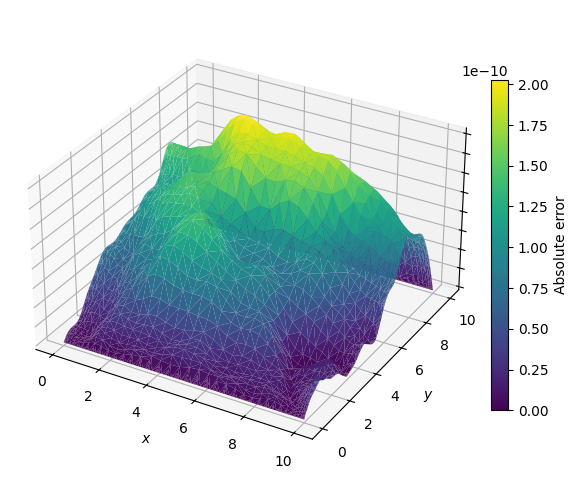

In [1]:
import numpy as np
from numpy.polynomial.legendre import legval, legder

import matplotlib.pyplot as plt
import matplotlib.tri as mtri

from scipy.linalg import lu_factor, lu_solve
import time


# ==========================================================
# Exact Solution and Right-Hand Side
# ==========================================================
def u_exact(x, y):

    return np.exp(-x) * (x + y**3)


def f_rhs(x, y):

    return np.exp(-x) * (x - 2 + y**3 + 6*y)


# ==========================================================
# Exact Derivatives Used for Neumann Data
# ==========================================================
def ux_exact(x, y):

    return np.exp(-x) * (1 - x - y**3)


def uy_exact(x, y):

    return 3 * np.exp(-x) * y**2


# ==========================================================
# Load Domain Points
# ==========================================================
interior_pts = np.load(
    "data/square_interior_points.npy"
)

boundary_pts = np.load(
    "data/square_boundary_points.npy"
)

print("Interior points :", interior_pts.shape[0])
print("Boundary points :", boundary_pts.shape[0])


# ==========================================================
# Basis Parameters
# ==========================================================
N_basis = 24

print("Total unknown :", N_basis**2)


# ==========================================================
# Separate Coordinates
# ==========================================================
xi_int, yi_int = interior_pts[:, 0], interior_pts[:, 1]
xi_b, yi_b     = boundary_pts[:, 0], boundary_pts[:, 1]

# ==========================================================
# Boundary Classification
# ==========================================================
# Dirichlet:
#   top and bottom boundaries
#
# Neumann:
#   left and right boundaries
#   excluding corner points
# ==========================================================
tol = 1e-12

is_top    = np.abs(yi_b - 10.0) < tol
is_bottom = np.abs(yi_b - 0.0)  < tol

is_left   = np.abs(xi_b - 0.0)  < tol
is_right  = np.abs(xi_b - 10.0) < tol


# ==========================================================
# Dirichlet boundaries own the corner points
# ==========================================================
is_dir = is_top | is_bottom


# ==========================================================
# Neumann boundaries exclude Dirichlet points
# ==========================================================
is_neu = (is_left | is_right) & (~is_dir)


# ==========================================================
# Extract Boundary Coordinates
# ==========================================================
xD, yD = xi_b[is_dir], yi_b[is_dir]

xN, yN = xi_b[is_neu], yi_b[is_neu]

print("Dirichlet pts :", xD.shape[0])
print("Neumann pts   :", xN.shape[0])

print("")


# ==========================================================
# Shifted Legendre Basis
# ==========================================================
def leg_shifted(n, x):

    # map [0,10] → [-1,1]
    x_hat = x / 5 - 1.0

    coeffs = [0] * n + [1]

    return legval(x_hat, coeffs)


# ==========================================================
# 2D Tensor Product Basis Matrix
# ==========================================================
def legendre_matrix_2d(x, y, N):

    cols = []

    for i in range(N):

        Px = leg_shifted(i, x)

        for j in range(N):

            Py = leg_shifted(j, y)

            cols.append(Px * Py)

    return np.vstack(cols).T


# ==========================================================
# Second Derivative Matrices
# ==========================================================
def legendre_derivative_matrices_2d(x, y, N):

    dxx_cols = []
    dyy_cols = []

    # ======================================================
    # Coordinate transformation:
    #
    # x_hat = x/5 - 1
    #
    # Chain rule:
    #
    # d²/dx² = (1/25)d²/dx_hat²
    # ======================================================
    x_hat = (x / 5) - 1.0
    y_hat = (y / 5) - 1.0

    scale = 1 / 25

    for i in range(N):

        ci = [0] * i + [1]

        d2ci = legder(legder(ci))

        Px   = legval(x_hat, ci)
        d2Px = scale * legval(x_hat, d2ci)

        for j in range(N):

            cj = [0] * j + [1]

            d2cj = legder(legder(cj))

            Py   = legval(y_hat, cj)
            d2Py = scale * legval(y_hat, d2cj)

            dxx_cols.append(d2Px * Py)
            dyy_cols.append(Px * d2Py)

    return np.vstack(dxx_cols).T, np.vstack(dyy_cols).T


# ==========================================================
# First Derivative Matrices
# Required for Neumann boundary conditions
# ==========================================================
def legendre_first_derivative_matrices_2d(x, y, N):

    dx_cols = []
    dy_cols = []

    x_hat = (x / 5) - 1.0
    y_hat = (y / 5) - 1.0

    scale = 1 / 5

    for i in range(N):

        ci = [0] * i + [1]

        dci = legder(ci)

        Px  = legval(x_hat, ci)
        dPx = scale * legval(x_hat, dci)

        for j in range(N):

            cj = [0] * j + [1]

            dcj = legder(cj)

            Py  = legval(y_hat, cj)
            dPy = scale * legval(y_hat, dcj)

            dx_cols.append(dPx * Py)
            dy_cols.append(Px * dPy)

    return np.vstack(dx_cols).T, np.vstack(dy_cols).T

# ==========================================================
# Assemble Basis Matrices
# ==========================================================
P_int = legendre_matrix_2d(
    xi_int,
    yi_int,
    N_basis
)

dxx_int, dyy_int = legendre_derivative_matrices_2d(
    xi_int,
    yi_int,
    N_basis
)

P_D = legendre_matrix_2d(
    xD,
    yD,
    N_basis
)

dx_N, dy_N = legendre_first_derivative_matrices_2d(
    xN,
    yN,
    N_basis
)


# ==========================================================
# RHS and Dirichlet Data
# ==========================================================
RHS_int   = f_rhs(xi_int, yi_int)

U_D_exact = u_exact(xD, yD)


# ==========================================================
# Outward Unit Normals
# ==========================================================
nx = np.zeros_like(xN)
ny = np.zeros_like(yN)


# ==========================================================
# Left boundary
# ==========================================================
mask = np.abs(xN - 0.0) < tol

nx[mask] = -1.0


# ==========================================================
# Right boundary
# ==========================================================
mask = np.abs(xN - 10.0) < tol

nx[mask] = 1.0


# ==========================================================
# Exact Neumann Data
# ==========================================================
gN = (
    ux_exact(xN, yN) * nx
    + uy_exact(xN, yN) * ny
)

start = time.time()
# ==========================================================
# Asymmetric Gaussian RBF
# ==========================================================
lam = 130.0

alpha = 0.9999

hx, hy = 1e-2, 1e-2


def rbf_matrix_asym(x, y, cx, cy):

    dx = x[:, None] - alpha * cx[None, :] + hx
    dy = y[:, None] - alpha * cy[None, :] + hy

    return np.exp(-lam * (dx**2 + dy**2))


# ==========================================================
# Boundary Centers
# ==========================================================
cx, cy = xi_b.copy(), yi_b.copy()


# ==========================================================
# Dirichlet Block
# ==========================================================
Phi_D = rbf_matrix_asym(
    xD,
    yD,
    cx,
    cy
)


# ==========================================================
# Neumann Block
# ==========================================================
dxN_rbf = xN[:, None] - alpha * cx[None, :] + hx
dyN_rbf = yN[:, None] - alpha * cy[None, :] + hy

r2N = dxN_rbf**2 + dyN_rbf**2

PhiN = np.exp(-lam * r2N)

PhiNx = (-2 * lam * dxN_rbf) * PhiN
PhiNy = (-2 * lam * dyN_rbf) * PhiN

Phi_Nn = (
    PhiNx * nx[:, None]
    + PhiNy * ny[:, None]
)


# ==========================================================
# Boundary System
# ==========================================================
A_bc = np.vstack([
    Phi_D,
    Phi_Nn
])

LU, piv = lu_factor(A_bc)


# ==========================================================
# Interior RBF Quantities
# ==========================================================
dx = xi_int[:, None] - alpha * cx[None, :] + hx
dy = yi_int[:, None] - alpha * cy[None, :] + hy

r2 = dx**2 + dy**2

Phi = np.exp(-lam * r2)

Phi_xx = (
    4 * lam**2 * dx**2 - 2 * lam
) * Phi

Phi_yy = (
    4 * lam**2 * dy**2 - 2 * lam
) * Phi

# ==========================================================
# Reduced Mixed-BC System
# ==========================================================

BC_beta = np.vstack([
    P_D,
    dx_N * nx[:, None]
    + dy_N * ny[:, None]
])

g_bc = np.concatenate([
    U_D_exact,
    gN
])

Ainv_BCbeta = lu_solve(
    (LU, piv),
    BC_beta
)

Ainv_gbc = lu_solve(
    (LU, piv),
    g_bc
)

J_beta = (
    dxx_int
    + dyy_int
    - Phi_xx @ Ainv_BCbeta
    - Phi_yy @ Ainv_BCbeta
)

rhs_red = (
    RHS_int
    - Phi_xx @ Ainv_gbc
    - Phi_yy @ Ainv_gbc
)

beta = np.linalg.lstsq(
    J_beta,
    rhs_red,
    rcond=None
)[0]

q = lu_solve(
    (LU, piv),
    g_bc - BC_beta @ beta
)

# ==========================================================
# Final Solution Evaluation
# ==========================================================
X_all = np.concatenate([xi_int, xi_b])
Y_all = np.concatenate([yi_int, yi_b])

P_all = legendre_matrix_2d(
    X_all,
    Y_all,
    N_basis
)


Phi_all = rbf_matrix_asym(
    X_all,
    Y_all,
    cx,
    cy
)

U_pred_all = (
    P_all @ beta
    + Phi_all @ q
)

end = time.time()

print("")
print("Time taken :", np.round((end - start), 2), "s")
print("")


# ==========================================================
# Residual and Error (Stage 2)
# ==========================================================
pde_res = np.linalg.norm(
    (dxx_int @ beta + Phi_xx @ q)
    + (dyy_int @ beta + Phi_yy @ q)
    - RHS_int
)

print(f"Residual after update = {pde_res:.2e}")

U_exact_all = u_exact(X_all, Y_all)
abs_error = np.abs(
    U_pred_all - U_exact_all
)

print("")

print(
    f"RMS error  = "
    f"{np.sqrt(np.mean(abs_error**2)):.2e}, "
    f"Linf error = "
    f"{np.max(abs_error):.2e}"
)


# ==========================================================
# Boundary Condition Verification
# ==========================================================

# ----------------------------------------------------------
# Dirichlet BC
# ----------------------------------------------------------
u_D_pred = P_D @ beta

psi_D = u_D_pred + Phi_D @ q

dir_err = np.abs(
    psi_D - U_D_exact
)


# ----------------------------------------------------------
# Neumann BC
# ----------------------------------------------------------
uNx_pred = dx_N @ beta
uNy_pred = dy_N @ beta

flux_pred = (
    uNx_pred * nx
    + uNy_pred * ny
)

flux_total = flux_pred + Phi_Nn @ q

neu_err = np.abs(
    flux_total - gN
)

print("")

print(f"Max Dirichlet error = {dir_err.max():.2e}")
print(f"Max Neumann error   = {neu_err.max():.2e}")


# ==========================================================
# Triangulation
# ==========================================================
triang = mtri.Triangulation(X_all, Y_all)
vmin_after  = 0.0
vmax_after  = abs_error.max()

fig2 = plt.figure(figsize=(6,6))
ax2 = fig2.add_subplot(111, projection='3d')

surf2 = ax2.plot_trisurf(
    triang,
    abs_error,
    cmap='viridis',
    vmin=vmin_after,
    vmax=vmax_after
)

ax2.set_xlabel(r"$x$")
ax2.set_ylabel(r"$y$")
ax2.set_zticklabels([])           # keep grid but hide z numbers
ax2.set_box_aspect((1,1,0.6))

cbar2 = fig2.colorbar(surf2, ax=ax2, shrink=0.58, pad=0.02)
cbar2.set_label("Absolute error")

plt.tight_layout()

plt.savefig("fig1m.pdf",dpi=300, bbox_inches="tight", pad_inches=0.15)


plt.show()
plt.close(fig2)